# 衡量效率

这里回顾一下装饰器（其实不是很难的东西），装饰器和高阶函数等价

In [61]:
def count(f):
    def counted(*args, **kwargs): #参数理应是n的，这里的意思是接收任意参数
        counted.call_count += 1
        return f(*args, **kwargs)
    counted.call_count = 0 #给函数定义属性
    return counted

此处count传入的参数就是被装饰的函数——fib，然后fib传入的参数对应其中counted（wrapper）传入的参数。<br>再说说运行过程，可以认为，你每一次调用fib就是调用counted（`fib = count(fib)`而count的返回值就是counted）。再看看counted内部，他给call_count这个属性+1（记录运行）

In [46]:
@count
def fib(n):
    if n == 0 or n == 1:
        return n
    else:
        return fib(n-1) + fib(n-2)

In [36]:
fib(30)

832040

In [37]:
fib.call_count

2692537

# 记忆化

把之前计算的结果记下来，不需要重复计算（缓存）

纯函数：
1. 输入决定输出
2. 无副作用

In [47]:
def memo(f): #只能用于纯函数
    cache = {} #传入参数：对应函数值的字典
    def memoized(n):
        if n not in cache:
            cache[n] = f(n)
        return cache[n]
    return memoized

In [48]:
fib = count(memo(fib))

In [49]:
fib(300)

222232244629420445529739893461909967206666939096499764990979600

In [50]:
fib.call_count

599

为何变快了呢？由于我们储存的是结果而非调用

# 示例幂运算

幂运算有两种定义：$$b^n =
\begin{cases}
1, & \text{if } n = 0,\\
b \cdot b^{n-1}, & \text{otherwise}.
\end{cases}$$
$$b^n =
\begin{cases}
1, & \text{if } n = 0,\\
\left(b^{\frac{1}{2}n}\right)^2, & \text{if } n \text{ is even},\\
b \cdot b^{n-1}, & \text{if } n \text{ is odd}.
\end{cases}$$

In [62]:
@count
def exp(b, n):
    return 1 if n == 0 else b * exp(b, n - 1)

@count
def exp_fast(b, n):
    if n == 0:
        return 1
    elif n % 2 == 0:
        return square(exp_fast(b, n//2))
    else:
        return b * exp(b, n - 1)
square = lambda x: x * x

注意到exp_fast最差情况也是奇偶交替，但当偶数的时候，n是指数递减的，这使得运算速度大大提升

In [63]:
exp(2, 1024)

179769313486231590772930519078902473361797697894230657273430081157732675805500963132708477322407536021120113879871393357658789768814416622492847430639474124377767893424865485276302219601246094119453082952085005768838150682342462881473913110540827237163350510684586298239947245938479716304835356329624224137216

In [64]:
exp_fast(2, 1024)

179769313486231590772930519078902473361797697894230657273430081157732675805500963132708477322407536021120113879871393357658789768814416622492847430639474124377767893424865485276302219601246094119453082952085005768838150682342462881473913110540827237163350510684586298239947245938479716304835356329624224137216

In [66]:
exp.call_count

1026

In [67]:
exp_fast.call_count

11

$11\approx \log_21026  + 1$

他们分别对应线性时间和对数时间

# 复杂度(Orders of Growth)

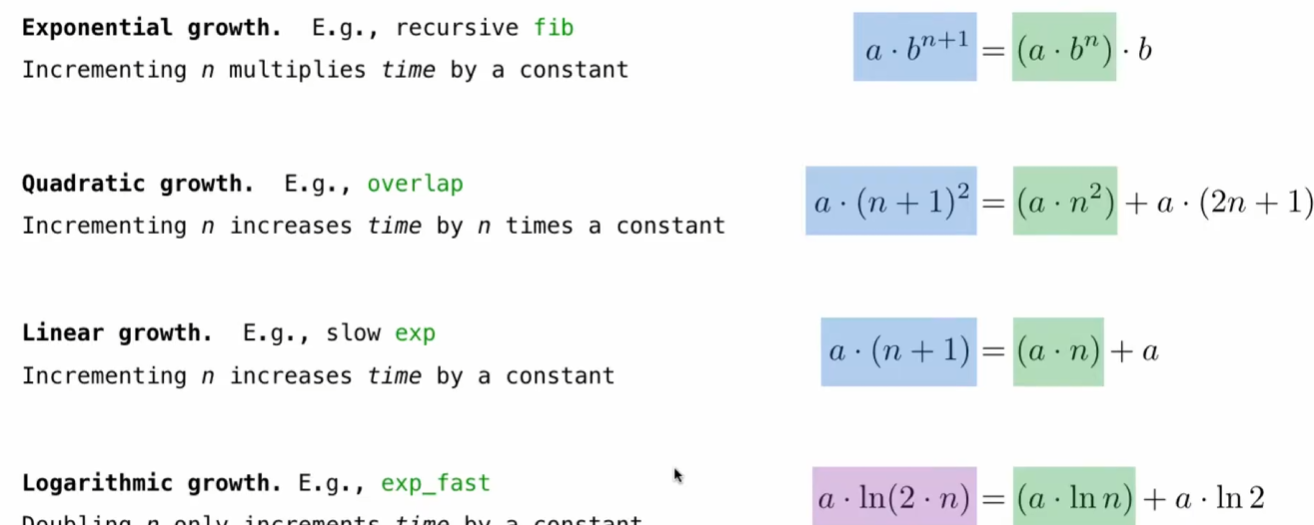

# 复杂度记号

计算理论的一个重要内容，就是基于数学定义来推理证明函数的特性

$\Theta(n^2)$和$O(n^2)$都能表示复杂度，前者规定了算法最多是二次复杂度，最小也是二次复杂度；后者则是规定上界是二次复杂度

# 空间

空间的消耗来源与各种value（长列表消耗的就比短列表多），Frame也会占用内存

但是，只有在active environments里的才会消耗内存（不在的会被回收）

活动环境就是：
1. 正在执行的函数调用
2. 在活动环境的函数的父环境<br>
后者的意思就是，例如在`fib(6)`计算的时候，需要f5、f4、f3、f2，在你算f2的时候，f3~5都在活动环境中

In [11]:
def count_frames(f):
    def counted(n):
        counted.open_count += 1
        if counted.open_count > counted.max_count:
            counted.max_count = counted.open_count
        result = f(n)
        counted.open_count -= 1
        return result
    counted.open_count = 0
    counted.max_count = 0
    return counted

In [12]:
@count_frames
def fib(n):
    return n if n == 0 or n == 1 else fib(n-2) + fib(n-1)

In [13]:
fib(5)

5

In [14]:
fib.open_count #因为函数调用结束了，打开的Frame数就是0

0

In [15]:
fib.max_count

5

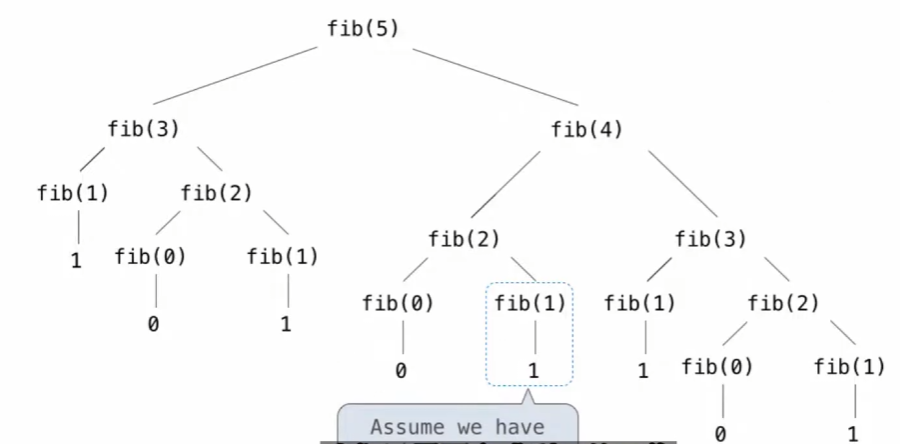